In [3]:
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import pyomo.environ as pe
import pyomo.opt as po

## Define the Graph

In [4]:
nodes = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
edges = {(0, 1), (0, 2), (0, 3), (1, 4),
         (1, 6), (2, 1), (2, 3), (2, 5),
         (3, 5), (4, 2), (5, 7), (5, 8),
         (6, 4), (6, 7), (6, 9), (7, 4),
         (7, 9), (8, 3), (8, 7), (8, 9)}
#Weight son los valores después de cada par ordenado, es decir las distancias, creo
distance = {(0, 1): 40, (0, 2):  8, (0, 3): 10, (1, 4):  6,
            (1, 6): 10, (2, 1):  4, (2, 3): 12, (2, 5):  2,
            (3, 5):  1, (4, 2):  2, (5, 7):  4, (5, 8):  3,
            (6, 4):  8, (6, 7): 20, (6, 9):  1, (7, 4):  0,
            (7, 9): 20, (8, 3):  6, (8, 7): 10, (8, 9):  2}

## Visualize Graph with NetworkX

In [5]:
graph = nx.DiGraph()
graph.add_nodes_from(list(nodes))
graph.add_edges_from(list(edges))
pos = ({0: (4, 0), 1: (0, 0), 2: (4, 2), 3: (8, 0), 4: (2, 4),
        5: (6, 4), 6: (0, 8), 7: (4, 6), 8: (8, 8), 9: (4, 8)})

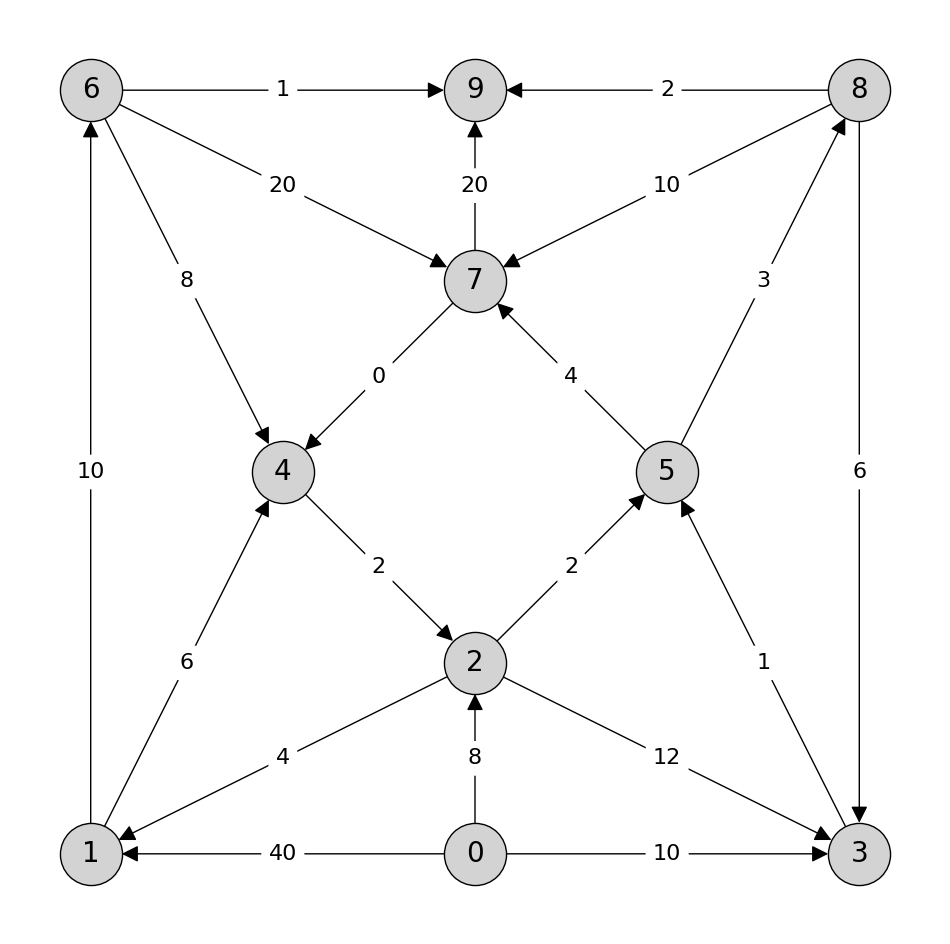

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))
nx.draw_networkx_nodes(graph, pos=pos, ax=ax, node_color='lightgray',
                       edgecolors='black', node_size=2000)
nx.draw_networkx_labels(graph, pos=pos, ax=ax, labels=dict(zip(nodes, nodes)),
                        font_size=20)
nx.draw_networkx_edges(graph, pos=pos, ax=ax, node_size=2000, arrowsize=25)
nx.draw_networkx_edge_labels(graph, pos=pos, ax=ax, edge_labels=distance,
                             font_size=16, rotate=False)
plt.axis('off')
plt.show()

## Define Sets of Incoming and Outgoing Edges
This data preprocessing step makes our lives easier when we define the flow balance constraints. For large graphs, doing this ahead of time in preprocessing (as opposed to on-the-fly during model construction) reduces instance build time from $\mathcal{O}(n^2)$ to $\mathcal{O}(n)$.

$Vm$ y $Vp$ son diccionarios cuyo valor por defecto es un set (conjunto).

$Vm$ se usará para guardar los vecinos hacia adelante (a dónde va cada nodo).

Vp$ se usará para guardar los vecinos hacia atrás (de dónde viene cada nodo)

In [7]:
Vm = defaultdict(set)
Vp = defaultdict(set)
for (i, j) in edges:
    Vm[i].add(j)
    Vp[j].add(i)

## Formulate the Shortest Path LP

sea $\mathcal{G} = (\mathcal{V}, \mathcal{E})$ el grafo. Sea $s$ y $t$ los nodos inicial y terminal, respectivamente, y sea $d_{ij}$ la distancia del nodo $i$ al nodo $j$. Como variables, sea $x_{ij}$ una variable 0-1 que indica la decisión de permitir flujo a través de la arista $(i, j)$. También introducimos la siguiente notación para describir nodos adyacentes en aristas entrantes y salientes.

\begin{aligned}
    \mathcal{V}^-(i) = \{j\ |\ (i, j) \in \mathcal{E}\} \\
    \mathcal{V}^+(i) = \{j\ |\ (j, i) \in \mathcal{E}\}
\end{aligned}

Requerimos que una unidad de flujo entre al grafo en el nodo inicial $s$ y que una unidad de flujo salga del grafo en el nodo terminal $t$. En cada otro nodo, requerimos balance de flujo. Nuestro objetivo es minimizar la longitud del camino que satisface las restricciones. Es decir, encontramos la suma ponderada por distancia de las variables $x_{i,j}$, el camino más corto.

$$
\begin{alignat*}{3}
\text{minimize  }  & \sum_{(i, j) \in \mathcal{E}} d_{ij} x_{ij} && \\
\text{subject to  }
& \sum_{j \in \mathcal{V}^-(s)} x_{sj} = 1 && \\
& \sum_{j \in \mathcal{V}^+(t)} x_{jt} = 1 && \\
& \sum_{j \in \mathcal{V}^+(i)} x_{ji} = \sum_{j \in \mathcal{V}^-(i)} x_{ij},
&& \qquad \forall i \in \mathcal{V} \setminus \{s, t\} \\
& x_{ij} \in \{0,1\},
&& \qquad \forall (i, j) \in \mathcal{E}
\end{alignat*}
$$

## Create the Model Object

In [8]:
model = pe.ConcreteModel()

## Define the Sets
Notice use of `within` when defining the set of edges. This ensures that $\mathcal{E} \subseteq \mathcal{V} \times \mathcal{V}$. While this is not necessary, it is good practice and will help identify data errors.

In [9]:
model.nodes = pe.Set(initialize=nodes)
model.edges = pe.Set(within=model.nodes*model.nodes, initialize=edges)

source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo


## Define the Parameters
El primer argumento de 'pe.Param' es el conjunto en el cual los parámetros están indexados. Por ejemplo, las distancias están definidas en el conjunto de aristas. El argumento initialize aquí debería ser una construcción tipo diccionario. Las llaves del diccionario deberían coincidir con el conjunto índice y los valores son... bueno... los valores. Nota también que $\mathcal{V}^+(\cdot)$ y $\mathcal{V}^-(\cdot)$ son conjuntos indexados, no técnicamente parámetros. Pyomo no soporta directamente conjuntos “irregulares” como este, pero usar pe.Param es una forma de implementar tal característica.

In [10]:
model.Vm = pe.Param(model.nodes, initialize=Vm, default=set(), within=pe.Any)
model.Vp = pe.Param(model.nodes, initialize=Vp, default=set(), within=pe.Any)
model.s = 0
model.t = 9
model.distance = pe.Param(model.edges, initialize=distance)

# Define the Variables
Just as it was with `pe.Param`, the first argument to `pe.Var` is the index set in which the variables are indexed. Optionally, we may define the domain of the variable set. Here, we require each $x_{i,j}$ to be binary -- either 0 or 1. If not explicitly defined, the domain is assumed to be the set of all real numbers (`pe.Reals`). The constraint matrix is totally unimodular. Consequently, the variables will assume integer values even if they are relaxed to the $[0, 1]$ interval. Below, we implement the relaxation using a combination of `domain` and `bounds`.

In [11]:
model.x = pe.Var(model.edges, domain=pe.Reals, bounds=(0, 1))

## Define the Objective
Unlike the previous examples in which we defined the objective using an `expr`, we now use a `rule`. What's the difference? The former just requires expression. The latter requires a function that returns an expression. And why would make it more complex by involving a function? Because it's modular! (Suppose we wanted to use this objective function in a bunch of other models. We can define it once in the function, then add it to a model with one line!)

In [12]:
def shortest_path(model):
    return sum(model.distance[i, j] * model.x[i, j]
               for (i, j) in model.edges)

model.obj_shortest_path = pe.Objective(sense=pe.minimize, rule=shortest_path)

## Define the Constraints
Similarly, we define the constraints using a rule (i.e., a function) instead of a bunch of expressions. We do this with a `pe.Constraint` instead of a `pe.ConstraintList` object. The positional arguments passed to `pe.Constraint` are the index sets over which the constraints are defined. In our case, there is one constraint per node, so we pass the just set of nodes.

In the general case, the constraints may be indexed in multiple node sets, say $A_1$ through $A_m$. Suppose we write the following function to use as our rule:

```
def constraint_rule(model, i_1, i_2, ..., i_m):
    ...
    return some_condition_based_on_arguments

```

Then

```
model.con = pe.Constraint(model.A_1, model.A_2, ..., model.A_m,
                          rule=constraint_rule)
```



is basically the same as

```
model.con = ConstraintList()
for i_1 in model.A_1:
    for i_2 in model.A_2:
        ...
            for i_m in model.A_m:
                model.con.add(constraint_rule(model, i_1, i_2, ... i_m))
```

That is, both impose a constraint for each combination of indices in the Cartesian product of all index sets.

This functional programming approach has a few advantages:
1. The nested for-loops we would otherwise have to write are handled implicitly.
2. We are able to access each constraint later by the defining combination of indices.
3. Again, modularity!

In [13]:
def flow_balance(model, i):
    flow_in = sum([model.x[j, i] for j in model.Vp[i]])
    flow_out = sum([model.x[i, j] for j in model.Vm[i]])
    if i == model.s:
        constraint = (flow_out == 1)
    elif i == model.t:
        constraint = (flow_in == 1)
    else:
        constraint = (flow_in == flow_out)
    return constraint

model.con_flow_balance = pe.Constraint(model.nodes, rule=flow_balance)

## Solve and Postprocess

In [15]:
solver = po.SolverFactory("glpk", executable="/opt/homebrew/bin/glpsol")
result = solver.solve(model, tee=True)

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmpp6my7ev5.glpk.raw
 --wglp /var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmp_glrqdaw.glpk.glp
 --cpxlp /var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmpi8zra_48.pyomo.lp
Reading problem data from '/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmpi8zra_48.pyomo.lp'...
10 rows, 20 columns, 40 non-zeros
118 lines were read
Writing problem data to '/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmp_glrqdaw.glpk.glp'...
114 lines were written
GLPK Simplex Optimizer 5.0
10 rows, 20 columns, 40 non-zeros
Preprocessing...
10 rows, 20 columns, 40 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 9
      0: obj =   1.000000000e+00 inf =   3.000e+00 (3)
      1: obj =   5.100000000e+01 inf =   0.000e+00 (0)
*     9: obj = 

Interpret the output to determine the shortest path.

In [16]:
i = int(model.s)
path_nodes = [i]
path_edges = []
stop = False
while not stop:
    for j in model.Vm[i]:
        if model.x[i, j].value == 1:
            if j == int(model.t):
                stop = True
            path_nodes.append(j)
            path_edges.append((i, j))
            i = j
            break

display(path_nodes)

[0, 2, 5, 8, 9]

## Visualize Solution with NetworkX

In [17]:
node_colors = ['lightblue' if i in path_nodes else 'lightgray'
               for i in graph.nodes()]
edge_colors = ['blue' if (i, j) in path_edges else 'black'
               for (i, j) in graph.edges()]
edge_widths = [2 if (i, j) in path_edges else 1
               for (i, j) in graph.edges()]

/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/ipykernel_22874/3156847396.py:6: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(graph, pos=pos, ax=ax, node_size=2000, arrowsize=25,


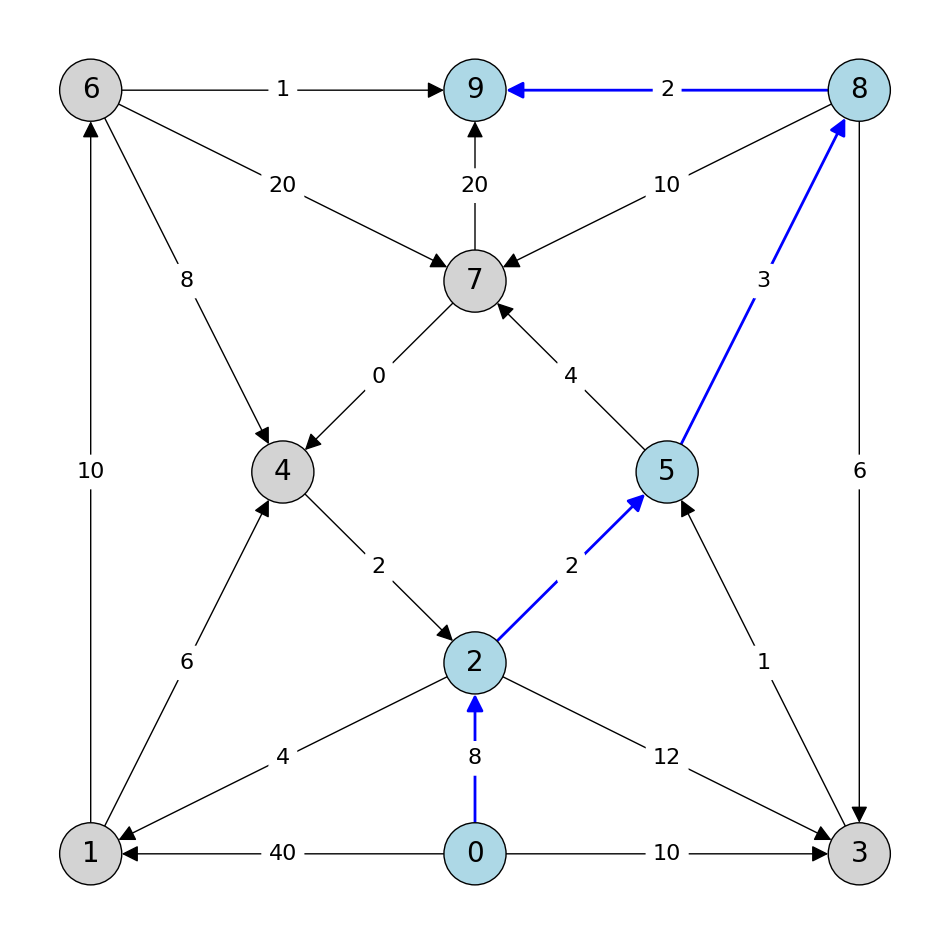

In [18]:
fig, ax = plt.subplots(figsize=(12, 12))
nx.draw_networkx_nodes(graph, pos=pos, ax=ax, node_color=node_colors,
                       edgecolors='black', node_size=2000)
nx.draw_networkx_labels(graph, pos=pos, ax=ax, labels=dict(zip(nodes, nodes)),
                        font_size=20)
nx.draw_networkx_edges(graph, pos=pos, ax=ax, node_size=2000, arrowsize=25,
                       edge_color=edge_colors, width=edge_widths)
nx.draw_networkx_edge_labels(graph, pos=pos, ax=ax, edge_labels=distance,
                             font_size=16, rotate=False)
plt.axis('off')
plt.show()